# Load Dataset

In [98]:
import pandas as pd

df = pd.read_csv("../data/final_balanced_multilingual_email_dataset.csv")

df.head()
df.shape
df.info()
df['label'].value_counts()
df['language'].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 8373 entries, 0 to 8372
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   text        8373 non-null   str  
 1   label       8373 non-null   str  
 2   language    8373 non-null   str  
 3   source      8373 non-null   str  
 4   clean_text  8373 non-null   str  
dtypes: str(5)
memory usage: 14.4 MB


language
English    6670
Malay      1703
Name: count, dtype: int64

In [99]:
X_text = df['clean_text']
y = df['label']

# 2.2 Feature Extraction

##Import Library

In [100]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

## Define X and y

In [101]:
X_text = df['clean_text']
y = df['label']

print("Text data shape:", X_text.shape)
print("Label distribution:")
print(y.value_counts())

Text data shape: (8373,)
Label distribution:
label
safe         4605
malicious    3768
Name: count, dtype: int64


## Feature Method 1: Bag of Words

In [102]:
bow_vectorizer = CountVectorizer(
    max_features=5000
)

X_bow = bow_vectorizer.fit_transform(X_text)

print("Bag of Words shape:", X_bow.shape)

Bag of Words shape: (8373, 5000)


## Feature Method 2: TF-IDF with N-grams

In [103]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_tfidf = tfidf_vectorizer.fit_transform(X_text)

print("TF-IDF shape:", X_tfidf.shape)

TF-IDF shape: (8373, 5000)


## Check feature names

In [104]:
bow_features = bow_vectorizer.get_feature_names_out()
tfidf_features = tfidf_vectorizer.get_feature_names_out()

print("Sample BoW features:")
print(bow_features[:30])

print("\nSample TF-IDF features:")
print(tfidf_features[:30])

Sample BoW features:
['abdv' 'ability' 'able' 'abroad' 'absence' 'absolute' 'absolutely'
 'abstract' 'abuse' 'academic' 'academics' 'acadia' 'accept' 'acceptable'
 'acceptance' 'accepted' 'accepting' 'access' 'accessories' 'accommodate'
 'accomplish' 'accomplished' 'accordance' 'according' 'accordingly'
 'account' 'accountant' 'accounting' 'accounts' 'accuracy']

Sample TF-IDF features:
['abdv' 'ability' 'able' 'absolutely' 'academic' 'acadia' 'accept'
 'acceptable' 'acceptance' 'acceptance terms' 'accepted' 'access'
 'accessories' 'according' 'account' 'accounting' 'accounting investment'
 'accounts' 'accuracy' 'accuracy completeness' 'accurate' 'achieve'
 'acquire' 'acquired' 'acquisition' 'acquisitions' 'acrobat' 'across'
 'act' 'act section']


# 2.3 Model Training

## Import Library

In [105]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pandas as pd

## Function to train and evaluate models

In [106]:
def train_and_evaluate(X, y, feature_name, model, model_name):
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # Train model
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label='malicious')
    recall = recall_score(y_test, y_pred, pos_label='malicious')
    f1 = f1_score(y_test, y_pred, pos_label='malicious')

    print("=" * 60)
    print(f"{feature_name} + {model_name}")
    print("=" * 60)
    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1-score :", f1)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    return {
        "Feature": feature_name,
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Trained Model": model,
        "X_test": X_test,
        "y_test": y_test,
        "y_pred": y_pred
    }

## Train all 4 combinations

In [107]:
results = []

# 1. BoW + Naive Bayes
results.append(
    train_and_evaluate(
        X_bow,
        y,
        "Bag of Words",
        MultinomialNB(),
        "Naive Bayes"
    )
)

# 2. BoW + Logistic Regression
results.append(
    train_and_evaluate(
        X_bow,
        y,
        "Bag of Words",
        LogisticRegression(max_iter=1000),
        "Logistic Regression"
    )
)

# 3. TF-IDF + Naive Bayes
results.append(
    train_and_evaluate(
        X_tfidf,
        y,
        "TF-IDF with N-grams",
        MultinomialNB(),
        "Naive Bayes"
    )
)

# 4. TF-IDF + Logistic Regression
results.append(
    train_and_evaluate(
        X_tfidf,
        y,
        "TF-IDF with N-grams",
        LogisticRegression(max_iter=1000),
        "Logistic Regression"
    )
)

Bag of Words + Naive Bayes
Accuracy : 0.9665671641791045
Precision: 0.9568062827225131
Recall   : 0.9694960212201591
F1-score : 0.9631093544137023

Classification Report:
              precision    recall  f1-score   support

   malicious       0.96      0.97      0.96       754
        safe       0.97      0.96      0.97       921

    accuracy                           0.97      1675
   macro avg       0.97      0.97      0.97      1675
weighted avg       0.97      0.97      0.97      1675


Confusion Matrix:
[[731  23]
 [ 33 888]]
Bag of Words + Logistic Regression
Accuracy : 0.968955223880597
Precision: 0.9546632124352331
Recall   : 0.9774535809018567
F1-score : 0.9659239842726082

Classification Report:
              precision    recall  f1-score   support

   malicious       0.95      0.98      0.97       754
        safe       0.98      0.96      0.97       921

    accuracy                           0.97      1675
   macro avg       0.97      0.97      0.97      1675
weighted a

# 2.4 Model Comparison

## Create comparison table

In [108]:
comparison_df = pd.DataFrame([
    {
        "Feature": r["Feature"],
        "Model": r["Model"],
        "Accuracy": r["Accuracy"],
        "Precision": r["Precision"],
        "Recall": r["Recall"],
        "F1-score": r["F1-score"]
    }
    for r in results
])

comparison_df = comparison_df.sort_values(by="F1-score", ascending=False)

comparison_df

,Feature,Model,Accuracy,Precision,Recall,F1-score
3,TF-IDF with N-grams,Logistic Regression,0.973731,0.963446,0.978780,0.971053
1,Bag of Words,Logistic Regression,0.968955,0.954663,0.977454,0.965924
0,Bag of Words,Naive Bayes,0.966567,0.956806,0.969496,0.963109
2,TF-IDF with N-grams,Naive Bayes,0.962985,0.954068,0.964191,0.959103


In [109]:
from pathlib import Path

Path("../visualizations").mkdir(exist_ok=True)

comparison_df.to_csv("../visualizations/model_comparison.csv", index=False)

print("Saved model comparison to ../visualizations/model_comparison.csv")
comparison_df

Saved model comparison to ../visualizations/model_comparison.csv


,Feature,Model,Accuracy,Precision,Recall,F1-score
3,TF-IDF with N-grams,Logistic Regression,0.973731,0.963446,0.978780,0.971053
1,Bag of Words,Logistic Regression,0.968955,0.954663,0.977454,0.965924
0,Bag of Words,Naive Bayes,0.966567,0.956806,0.969496,0.963109
2,TF-IDF with N-grams,Naive Bayes,0.962985,0.954068,0.964191,0.959103


## Select best model

In [110]:
best_result = max(results, key=lambda x: x["F1-score"])

print("Best Feature:", best_result["Feature"])
print("Best Model:", best_result["Model"])
print("Best F1-score:", best_result["F1-score"])

Best Feature: TF-IDF with N-grams
Best Model: Logistic Regression
Best F1-score: 0.9710526315789474


In [111]:
from pathlib import Path
import pandas as pd

# Create visualizations folder if it does not exist
output_folder = Path("../visualizations")
output_folder.mkdir(exist_ok=True)

# Save test actual labels and predicted labels
test_predictions_df = pd.DataFrame({
    "y_test": y_test_best,
    "y_pred": y_pred_best
})

test_predictions_df.to_csv("../visualizations/best_test_predictions.csv", index=False)

print("Saved test predictions to ../visualizations/best_test_predictions.csv")
print(test_predictions_df.head())

Saved test predictions to ../visualizations/best_test_predictions.csv
         y_test     y_pred
4374       safe       safe
7540       safe       safe
1136       safe       safe
6566       safe       safe
5700  malicious  malicious


# Save Best Model and Vectorizer

In [112]:
import joblib

best_model = best_result["Trained Model"]

if best_result["Feature"] == "TF-IDF with N-grams":
    best_vectorizer = tfidf_vectorizer
    vectorizer_name = "tfidf_vectorizer.pkl"
else:
    best_vectorizer = bow_vectorizer
    vectorizer_name = "bow_vectorizer.pkl"

joblib.dump(best_model, "best_email_threat_model.pkl")
joblib.dump(best_vectorizer, vectorizer_name)

print("Best model saved as: best_email_threat_model.pkl")
print("Vectorizer saved as:", vectorizer_name)

Best model saved as: best_email_threat_model.pkl
Vectorizer saved as: tfidf_vectorizer.pkl


# Manual Spam/Phishing Email Testing

## Load Best Model and Vectorizer

In [113]:
import joblib

model = joblib.load("best_email_threat_model.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")  # change if your best vectorizer is BoW

## Use Same Cleaning Function

In [114]:
import re
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

english_stopwords = set(stopwords.words('english'))

malay_stopwords = {
    'yang', 'dan', 'di', 'ke', 'dari', 'untuk', 'dengan', 'ini', 'itu',
    'anda', 'saya', 'kami', 'kita', 'adalah', 'akan', 'telah', 'sebagai',
    'dalam', 'pada', 'tidak', 'boleh', 'atau', 'juga', 'lebih', 'serta',
    'kerana', 'oleh', 'hingga', 'sila', 'adakah', 'kepada', 'mereka',
    'semua', 'sudah', 'belum', 'lagi', 'jika', 'seperti', 'hanya',
    'tersebut', 'ialah', 'iaitu'
}

all_stopwords = english_stopwords.union(malay_stopwords)

def clean_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)

    # Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords and short words
    tokens = [
        word for word in tokens
        if word not in all_stopwords and len(word) > 2
    ]

    return ' '.join(tokens)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\harri\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\harri\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\harri\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Test English Spam Email

In [115]:
test_emails = [
    {
        "Email": "Congratulations! You have won a free iPhone. Click here to claim now.",
        "Expected": "malicious"
    },
    {
        "Email": "Hi team, please find attached the meeting agenda for tomorrow.",
        "Expected": "safe"
    },
    {
        "Email": "Akaun bank anda telah disekat. Sila klik pautan ini untuk sahkan akaun anda.",
        "Expected": "malicious"
    },
    {
        "Email": "Salam, kelas esok akan bermula pada pukul 10 pagi. Sila bawa nota kuliah.",
        "Expected": "safe"
    }
]

manual_results = []

for item in test_emails:
    cleaned = clean_text(item["Email"])
    vectorized = vectorizer.transform([cleaned])
    prediction = model.predict(vectorized)[0]

    if hasattr(model, "predict_proba"):
        confidence = max(model.predict_proba(vectorized)[0]) * 100
    else:
        confidence = None

    manual_results.append({
        "Email": item["Email"],
        "Expected": item["Expected"],
        "Predicted": prediction,
        "Confidence (%)": round(confidence, 2) if confidence is not None else "N/A"
    })

manual_test_df = pd.DataFrame(manual_results)
manual_test_df

,Email,Expected,Predicted,Confidence (%)
0,Congratulations! You have won a free iPhone. C...,malicious,malicious,84.62
1,"Hi team, please find attached the meeting agen...",safe,safe,93.39
2,Akaun bank anda telah disekat. Sila klik pauta...,malicious,malicious,95.14
3,"Salam, kelas esok akan bermula pada pukul 10 p...",safe,malicious,53.15


## Manual Testing Email

In [116]:
# ===============================
# Manual Email Threat Detection
# ===============================

import joblib

# Load saved model and vectorizer
model = joblib.load("best_email_threat_model.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")  # change if your best vectorizer is BoW

# Ask user to enter email text
user_email = input("Enter email text to check: ")

# Clean the new email using the same preprocessing function
cleaned_email = clean_text(user_email)

# Convert text into numerical features
email_vector = vectorizer.transform([cleaned_email])

# Predict
prediction = model.predict(email_vector)[0]

# Confidence score
if hasattr(model, "predict_proba"):
    probabilities = model.predict_proba(email_vector)[0]
    confidence = max(probabilities) * 100
else:
    confidence = None

# Display result
print("\n==============================")
print("EMAIL THREAT DETECTION RESULT")
print("==============================")
print("Original Email:")
print(user_email)

print("\nCleaned Email:")
print(cleaned_email)

print("\nPrediction:")

if prediction == "malicious":
    print("🚨 MALICIOUS EMAIL DETECTED")
    print("This email may be spam or phishing.")
else:
    print("✅ SAFE EMAIL")
    print("This email appears to be legitimate.")

if confidence is not None:
    print(f"\nConfidence Score: {confidence:.2f}%")


EMAIL THREAT DETECTION RESULT
Original Email:


Cleaned Email:


Prediction:
🚨 MALICIOUS EMAIL DETECTED
This email may be spam or phishing.

Confidence Score: 53.15%


#Visualization Section Code

In [117]:
# ===============================
# Step 2.5 Visualization & Error Analysis
# ===============================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Model Comparison Bar Chart

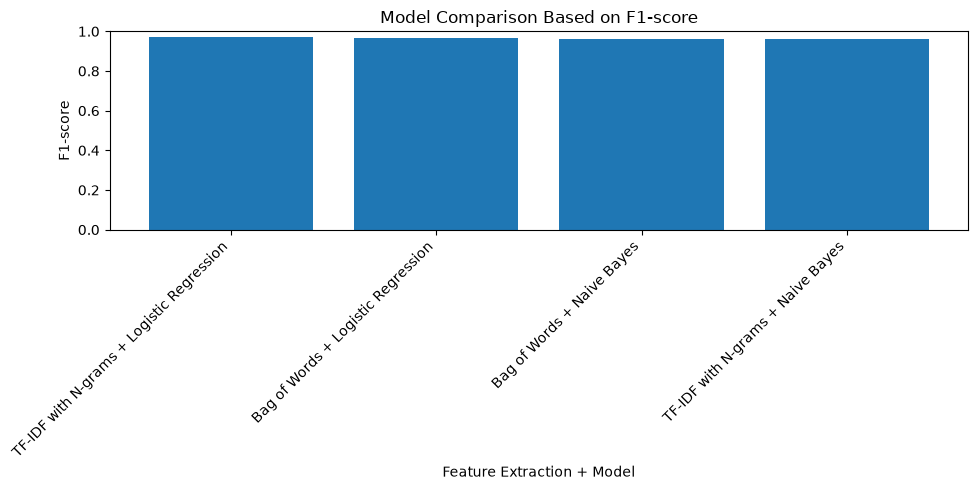

In [118]:
# Sort models by F1-score
comparison_plot_df = comparison_df.sort_values(by="F1-score", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(
    comparison_plot_df["Feature"] + " + " + comparison_plot_df["Model"],
    comparison_plot_df["F1-score"]
)

plt.title("Model Comparison Based on F1-score")
plt.xlabel("Feature Extraction + Model")
plt.ylabel("F1-score")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

Accuracy, Precision, Recall, F1-score Comparison

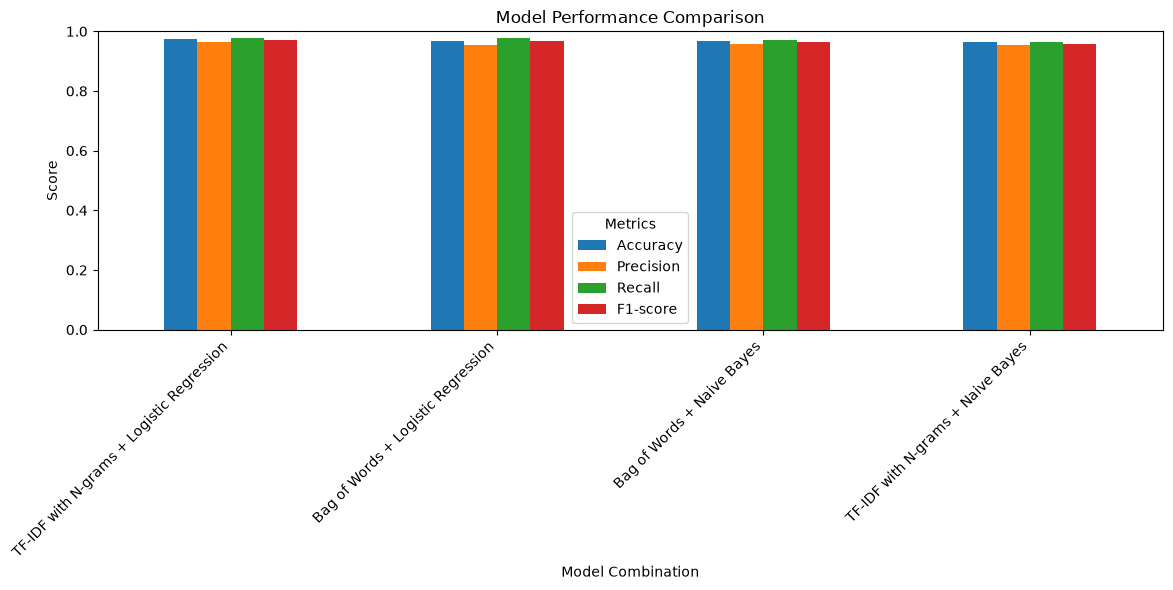

In [119]:
metrics_df = comparison_df.copy()

metrics_df["Model Combination"] = metrics_df["Feature"] + " + " + metrics_df["Model"]

metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-score"]

metrics_df.set_index("Model Combination")[metrics_to_plot].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model Combination")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

Confusion Matrix Heatmap for Best Model

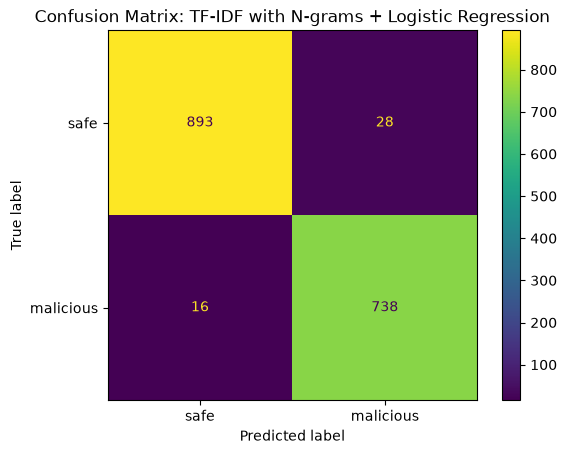

In [120]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from pathlib import Path
import matplotlib.pyplot as plt

best_result = max(results, key=lambda x: x["F1-score"])

best_feature = best_result["Feature"]
best_model_name = best_result["Model"]
y_test_best = best_result["y_test"]
y_pred_best = best_result["y_pred"]

cm = confusion_matrix(
    y_test_best,
    y_pred_best,
    labels=["safe", "malicious"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["safe", "malicious"]
)

disp.plot(values_format="d")
plt.title(f"Confusion Matrix: {best_feature} + {best_model_name}")

# Create images folder if it does not exist
Path("../images").mkdir(exist_ok=True)

# Save the confusion matrix image
plt.savefig("../images/test_confusion_matrix_heatmap.png", bbox_inches="tight", dpi=300)

plt.show()

Confusion Matrix for All 4 Models

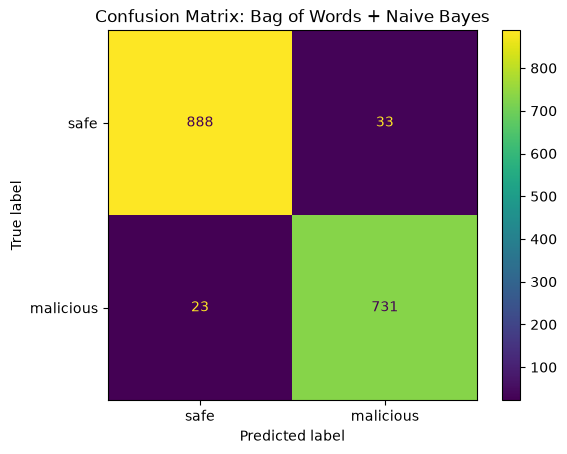

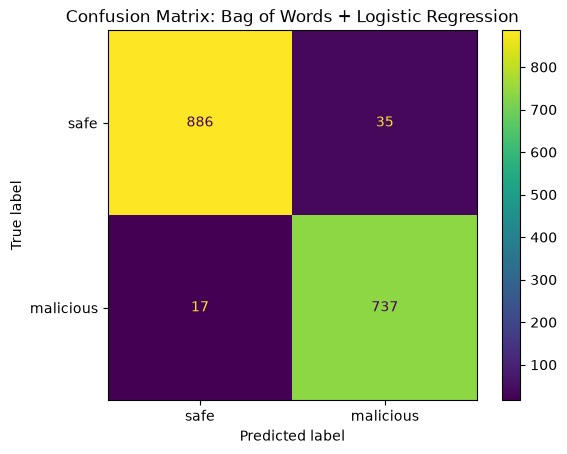

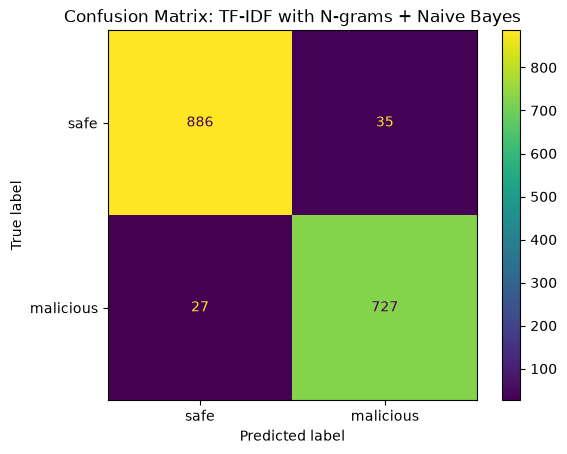

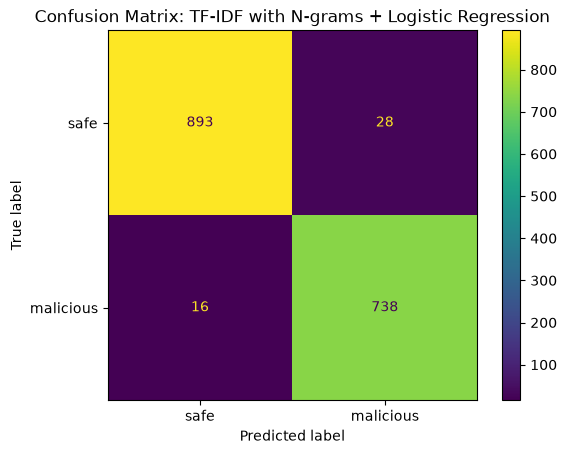

In [121]:
for r in results:
    cm = confusion_matrix(
        r["y_test"],
        r["y_pred"],
        labels=["safe", "malicious"]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["safe", "malicious"]
    )

    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix: {r['Feature']} + {r['Model']}")
    plt.show()

False Positive and False Negative Analysis

False Positive = Safe email predicted as malicious

False Negative = Malicious email predicted as safe

In [122]:
error_df = pd.DataFrame({
    "Actual": y_test_best,
    "Predicted": y_pred_best
})

false_positive = error_df[
    (error_df["Actual"] == "safe") &
    (error_df["Predicted"] == "malicious")
]

false_negative = error_df[
    (error_df["Actual"] == "malicious") &
    (error_df["Predicted"] == "safe")
]

print("False Positive count:", len(false_positive))
print("False Negative count:", len(false_negative))

False Positive count: 28
False Negative count: 16


False Positive vs False Negative Bar Chart

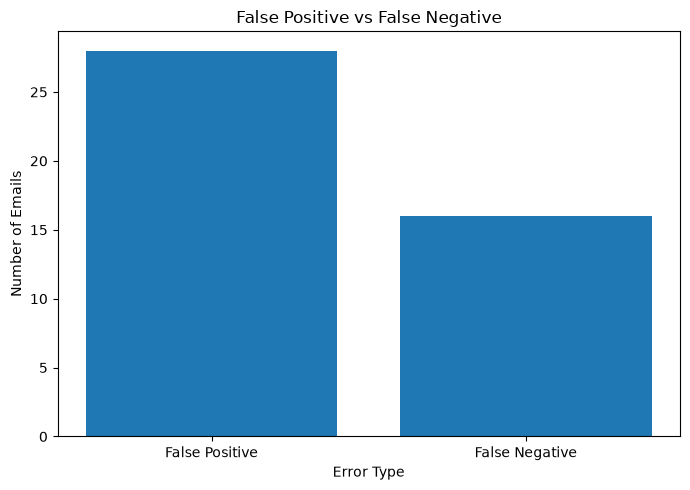

In [123]:
error_counts = pd.DataFrame({
    "Error Type": ["False Positive", "False Negative"],
    "Count": [len(false_positive), len(false_negative)]
})

plt.figure(figsize=(7, 5))
plt.bar(error_counts["Error Type"], error_counts["Count"])

plt.title("False Positive vs False Negative")
plt.xlabel("Error Type")
plt.ylabel("Number of Emails")
plt.tight_layout()
plt.show()

Correct vs Incorrect Prediction Chart

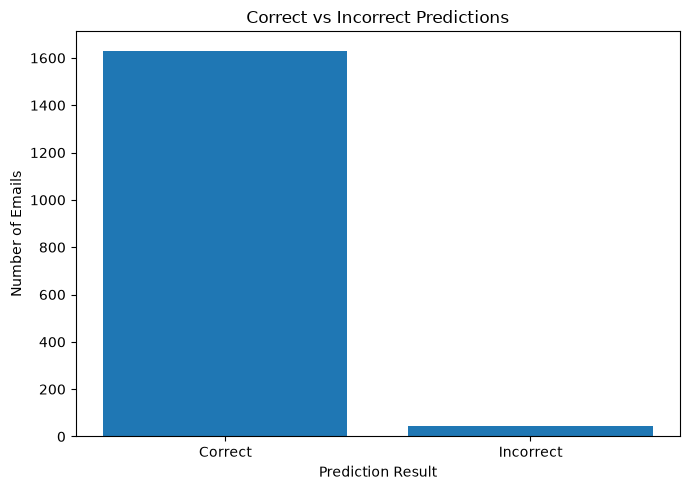

In [124]:
correct_predictions = (error_df["Actual"] == error_df["Predicted"]).sum()
incorrect_predictions = (error_df["Actual"] != error_df["Predicted"]).sum()

prediction_summary = pd.DataFrame({
    "Prediction Result": ["Correct", "Incorrect"],
    "Count": [correct_predictions, incorrect_predictions]
})

plt.figure(figsize=(7, 5))
plt.bar(prediction_summary["Prediction Result"], prediction_summary["Count"])

plt.title("Correct vs Incorrect Predictions")
plt.xlabel("Prediction Result")
plt.ylabel("Number of Emails")
plt.tight_layout()
plt.show()

Actual vs Predicted Class Distribution

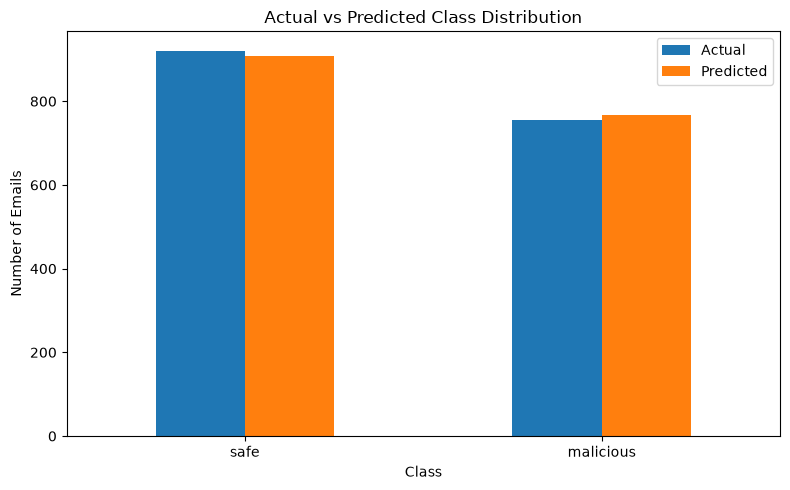

In [125]:
actual_counts = y_test_best.value_counts()
predicted_counts = pd.Series(y_pred_best).value_counts()

class_distribution_df = pd.DataFrame({
    "Actual": actual_counts,
    "Predicted": predicted_counts
}).fillna(0)

class_distribution_df.plot(kind="bar", figsize=(8, 5))

plt.title("Actual vs Predicted Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Emails")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()